In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:

df=sns.load_dataset("healthexp")
df.head(20)


,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9
5,1971,Canada,313.391,72.8
6,1971,Germany,298.251,70.8
7,1971,Great Britain,134.172,71.9
8,1971,Japan,163.854,72.9
9,1971,USA,357.988,71.2


In [5]:
df.shape

(274, 4)

In [6]:
df.sort_values(by='Spending_USD')[['Country', 'Year', 'Spending_USD', 'Life_Expectancy']]

,Country,Year,Spending_USD,Life_Expectancy
2,Great Britain,1970,123.993,71.9
7,Great Britain,1971,134.172,71.9
3,Japan,1970,150.437,72.0
8,Japan,1971,163.854,72.9
11,Japan,1972,185.390,73.2
...,...,...,...,...
249,USA,2016,9717.649,78.7
255,USA,2017,10046.472,78.6
261,USA,2018,10451.386,78.7
267,USA,2019,10855.517,78.8


In [7]:
df.shape

(274, 4)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             274 non-null    int64  
 1   Country          274 non-null    object 
 2   Spending_USD     274 non-null    float64
 3   Life_Expectancy  274 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 8.7+ KB


In [9]:
df.isnull().sum()

Year               0
Country            0
Spending_USD       0
Life_Expectancy    0
dtype: int64

In [10]:
df.shape

(274, 4)

In [11]:
# df.duplicated().sum()
df.duplicated(subset=['Year','Country']).sum()

np.int64(0)

# comparing spending_USD and life expectancy

In [12]:
print(df['Spending_USD'].describe())
print("median:",df['Spending_USD'].median())

count      274.000000
mean      2789.338905
std       2194.939785
min        123.993000
25%       1038.357000
50%       2295.578000
75%       4055.610000
max      11859.179000
Name: Spending_USD, dtype: float64
median: 2295.578


In [13]:
print(df['Life_Expectancy'].describe())
print("median:",df['Life_Expectancy'].median())

count    274.000000
mean      77.909489
std        3.276263
min       70.600000
25%       75.525000
50%       78.100000
75%       80.575000
max       84.700000
Name: Life_Expectancy, dtype: float64
median: 78.1


#Distribution analysis of spending_USD and Life Expectancy

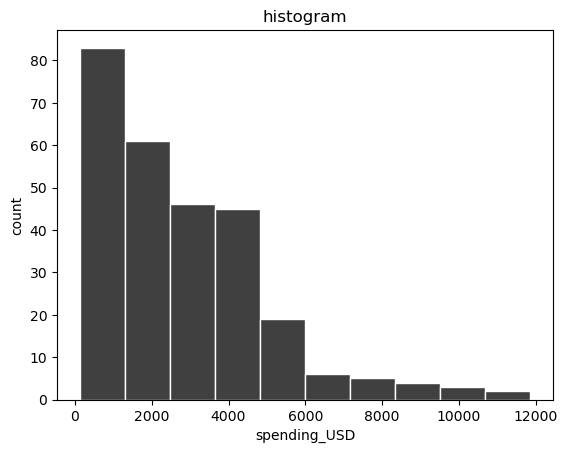

In [34]:
plt.Figure(figsize=(10,15))
sns.histplot(df['Spending_USD'],color='black',bins=10,edgecolor='white')
plt.xlabel("spending_USD")
plt.ylabel("count")
plt.title("histogram")
plt.show()

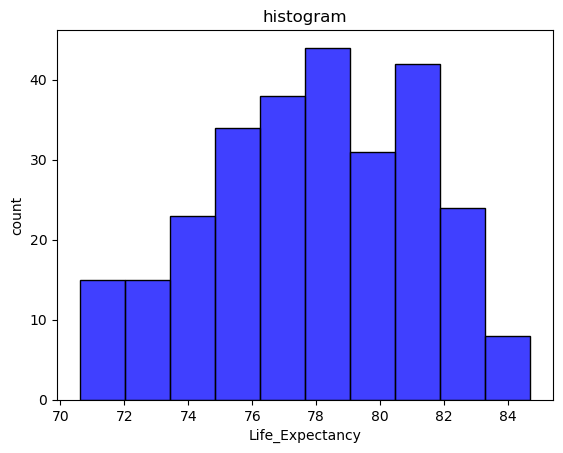

In [15]:
plt.Figure(figsize=(10,15))
sns.histplot(df['Life_Expectancy'],color='blue',bins=10,edgecolor='black')
plt.xlabel("Life_Expectancy")
plt.ylabel("count")
plt.title("histogram")
plt.show()

#Boxplot of Spending_USD

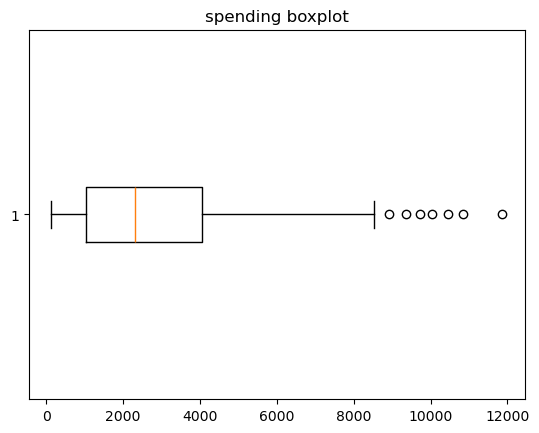

In [16]:
plt.boxplot(df['Spending_USD'],vert=False)
plt.title("spending boxplot")
plt.show()

In [17]:
def detect_outliers_iqr(df,Spending_USD):
 Q1=df[Spending_USD].quantile(0.25)
 Q3=df[Spending_USD].quantile(0.75)
 IQR=Q3-Q1
 lower_bound=Q1-1.5*IQR
 upper_bound=Q3+1.5*IQR
 outliers=df[(df[Spending_USD]<lower_bound)| (df[Spending_USD]>upper_bound)]
 return outliers,Q1,Q3,lower_bound,upper_bound

outliers,Q1,Q3,lower_bound,upper_bound=detect_outliers_iqr(df,'Spending_USD')

print("Q1:",Q1)
print("Q3:",Q3)
print("lower_bound:",lower_bound)
print("upper_bound:",upper_bound)

print("Number of outliers detected:",len(outliers))
outliers

Q1: 1038.357
Q3: 4055.61
lower_bound: -3487.5225
upper_bound: 8581.4895
Number of outliers detected: 7


,Year,Country,Spending_USD,Life_Expectancy
237,2014,USA,8925.879,78.9
243,2015,USA,9355.118,78.7
249,2016,USA,9717.649,78.7
255,2017,USA,10046.472,78.6
261,2018,USA,10451.386,78.7
267,2019,USA,10855.517,78.8
273,2020,USA,11859.179,77.0


i did not remove the outliers because these may be the real value instead of any error

#Boxplot of life Expectancy

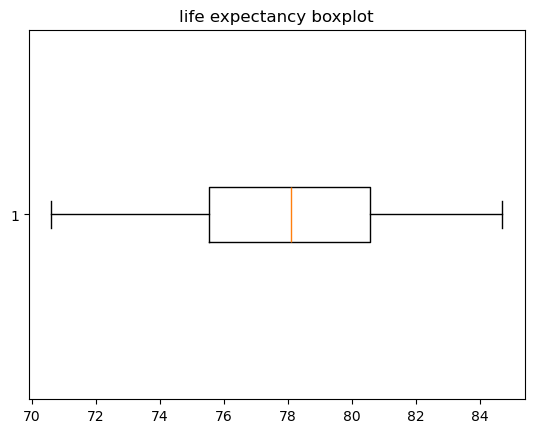

In [18]:
plt.boxplot(df['Life_Expectancy'],vert=False)
plt.title("life expectancy boxplot")
plt.show()

No, outliers

#Scatter plot of spending and life expectancy

<function matplotlib.pyplot.ylabel(ylabel: 'str', fontdict: 'dict[str, Any] | None' = None, labelpad: 'float | None' = None, *, loc: "Literal['bottom', 'center', 'top'] | None" = None, **kwargs) -> 'Text'>

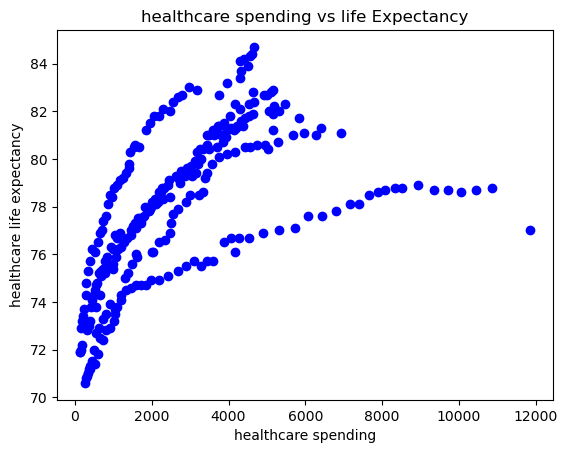

In [19]:
x=df['Spending_USD']
y=df['Life_Expectancy']
plt.Figure(figsize=(25,30))
plt.scatter(x,y,color='blue',marker='o',alpha=1)
plt.xlabel('healthcare spending')
plt.ylabel('healthcare life expectancy')
plt.title('healthcare spending vs life Expectancy')
plt.ylabel

In [22]:
Avg_spending = df.groupby('Year')['Spending_USD'].mean()
print(Avg_spending)

Year
1970     209.169000
1971     253.531200
1972     306.617000
1973     343.207000
1974     396.625333
1975     435.277500
1976     519.252750
1977     571.407000
1978     643.639333
1979     713.716500
1980     719.369833
1981     828.595800
1982     896.707400
1983     968.013200
1984    1037.950000
1985    1102.616000
1986    1190.312800
1987    1273.074800
1988    1386.068200
1989    1472.263600
1990    1573.295167
1991    1654.811600
1992    1808.727000
1993    1889.864333
1994    1979.827667
1995    2088.205167
1996    2236.056167
1997    2292.668833
1998    2382.190333
1999    2503.543000
2000    2719.200833
2001    2901.699333
2002    3136.497000
2003    3281.663167
2004    3463.823833
2005    3603.304833
2006    3803.356500
2007    3987.788167
2008    4154.351667
2009    4322.644333
2010    4518.969500
2011    4712.202167
2012    4885.364833
2013    5070.150333
2014    5221.396000
2015    5379.151667
2016    5602.519167
2017    5774.139667
2018    5980.812000
2019    6102.87

#Average spending relative to year

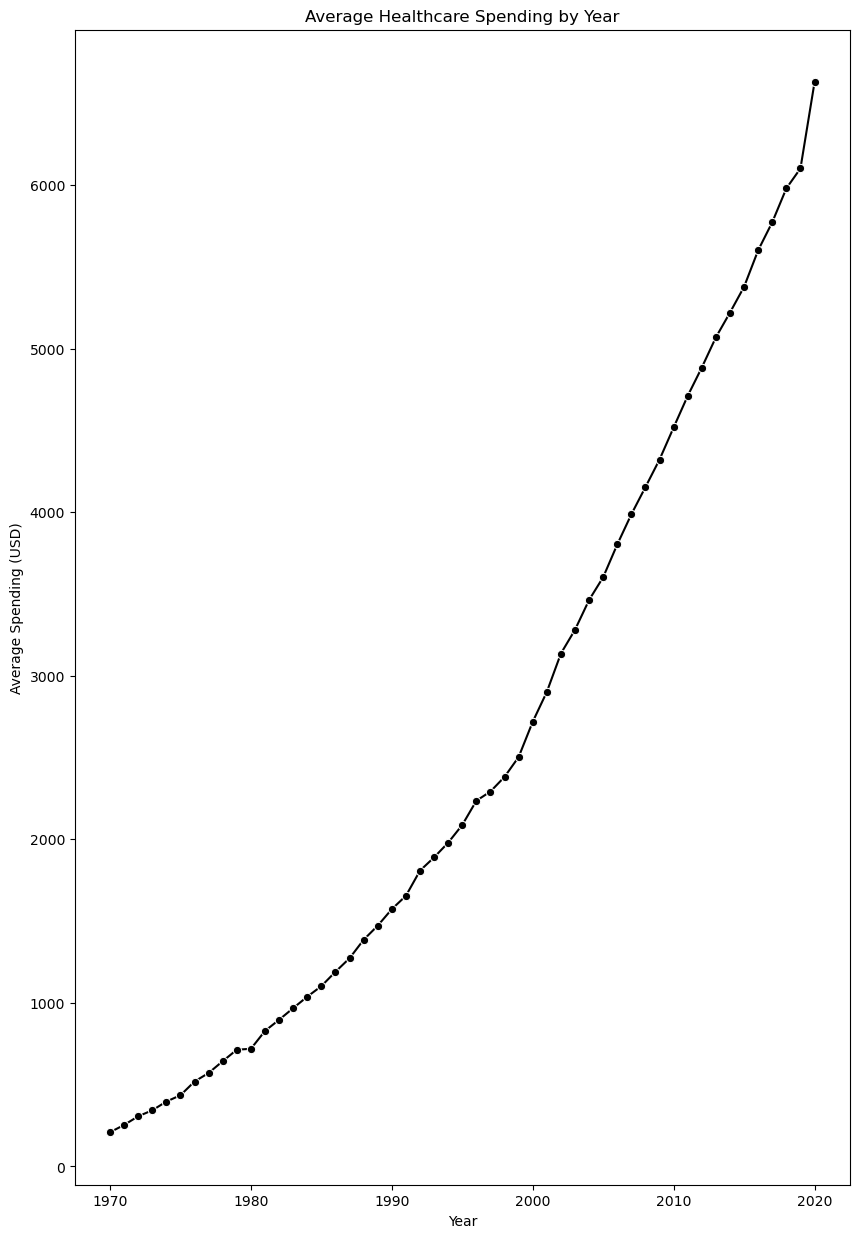

In [26]:


avg_spending = (
    df.groupby('Year', as_index=False)['Spending_USD']
      .mean()
)

plt.figure(figsize=(10,15))

sns.lineplot(
    data=avg_spending,
    x='Year',
    y='Spending_USD',
    marker='o',
    color='black'
)

plt.title("Average Healthcare Spending by Year")
plt.xlabel("Year")
plt.ylabel("Average Spending (USD)")

plt.show()

#Average life expectancy relative to year

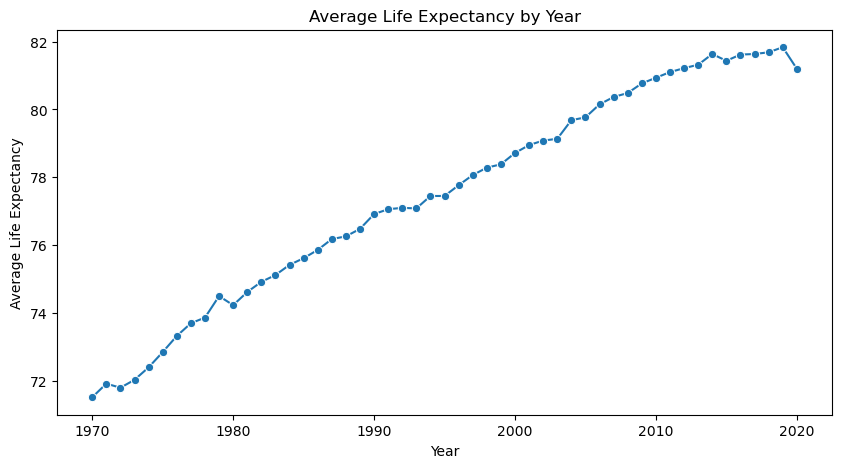

In [25]:
avg_life = (
    df.groupby('Year', as_index=False)['Life_Expectancy']
      .mean()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=avg_life,
    x='Year',
    y='Life_Expectancy',
    marker='o'
)

plt.title("Average Life Expectancy by Year")
plt.xlabel("Year")
plt.ylabel("Average Life Expectancy")

plt.show()

#Average spending by country

In [ ]:
avg_spending = (df.groupby('Country', as_index=False)['Spending_USD'].mean())
print(avg_spending)

         Country  Spending_USD
0         Canada   2685.778341
1         France   3045.145057
2        Germany   2667.280200
3  Great Britain   2034.192465
4          Japan   1860.257902
5            USA   4388.570529


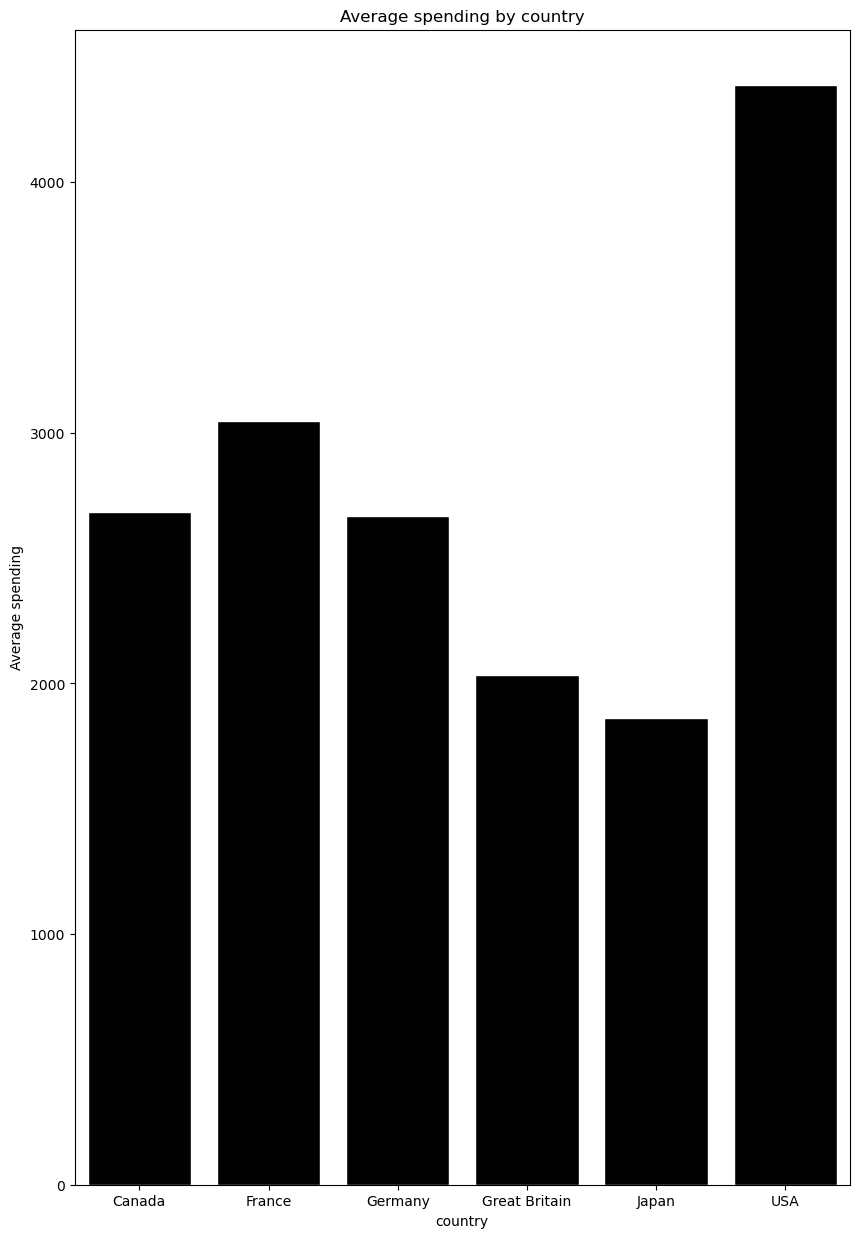

In [32]:
plt.figure(figsize=(10,15))

sns.barplot(
    data=avg_spending,
    x='Country',
    y='Spending_USD',
    color='black',
    edgecolor='white'

    # marker='o'
)

plt.title("Average spending by country")
plt.xlabel("country")
plt.ylabel("Average spending")

plt.show()

#Average life expectancy by country

In [35]:
avg_lifeExpectancy = (df.groupby('Country', as_index=False)['Life_Expectancy'].mean())
print(avg_lifeExpectancy)


         Country  Life_Expectancy
0         Canada        78.706818
1         France        79.565714
2        Germany        76.726000
3  Great Britain        77.620930
4          Japan        79.554902
5            USA        75.843137


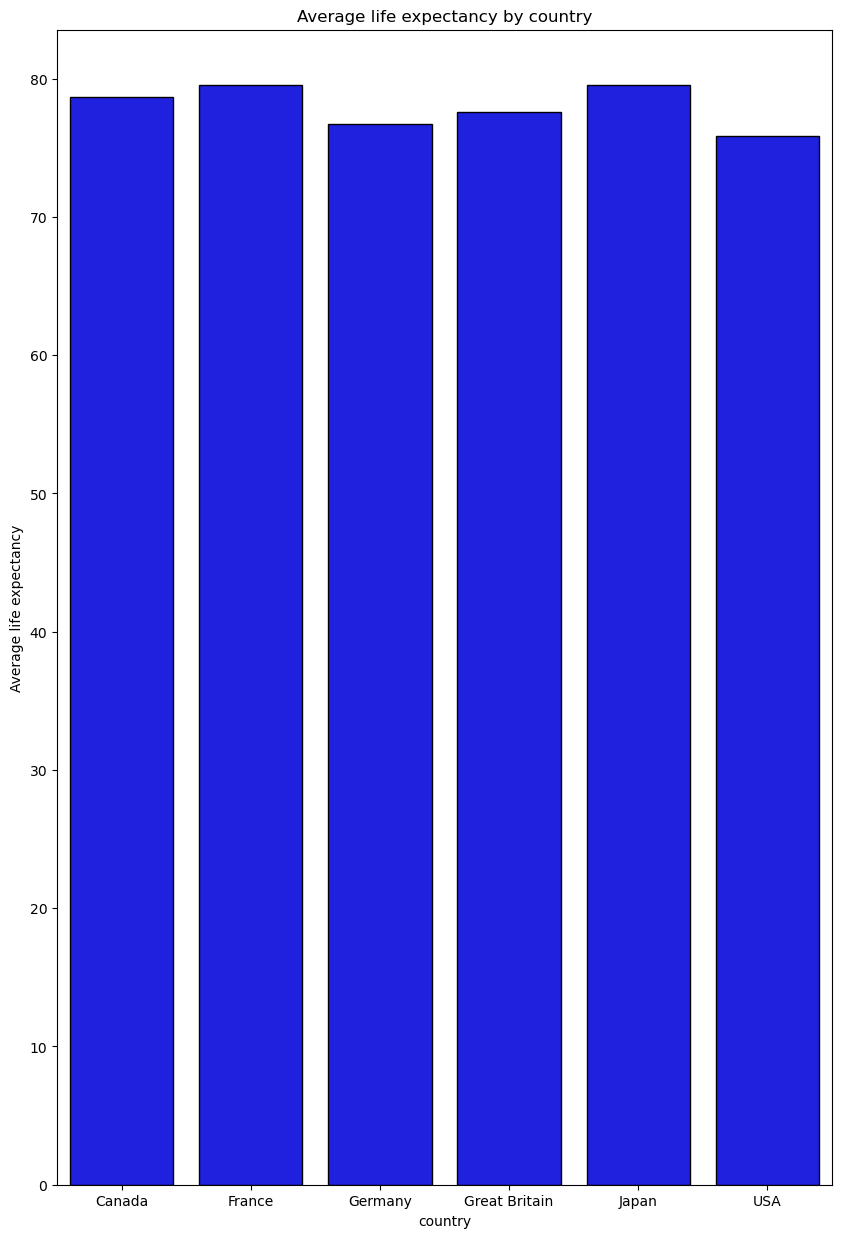

In [36]:
plt.figure(figsize=(10,15))

sns.barplot(
    data=avg_lifeExpectancy,
    x='Country',
    y='Life_Expectancy',
    color='blue',
    edgecolor='black'

    # marker='o'
)

plt.title("Average life expectancy by country")
plt.xlabel("country")
plt.ylabel("Average life expectancy")
plt.show()

#Correlation between Spending_USD and Life_Expectancy

In [55]:
correlation=df[['Spending_USD','Life_Expectancy']].corr()
print(correlation)


                 Spending_USD  Life_Expectancy
Spending_USD          1.00000          0.57943
Life_Expectancy       0.57943          1.00000


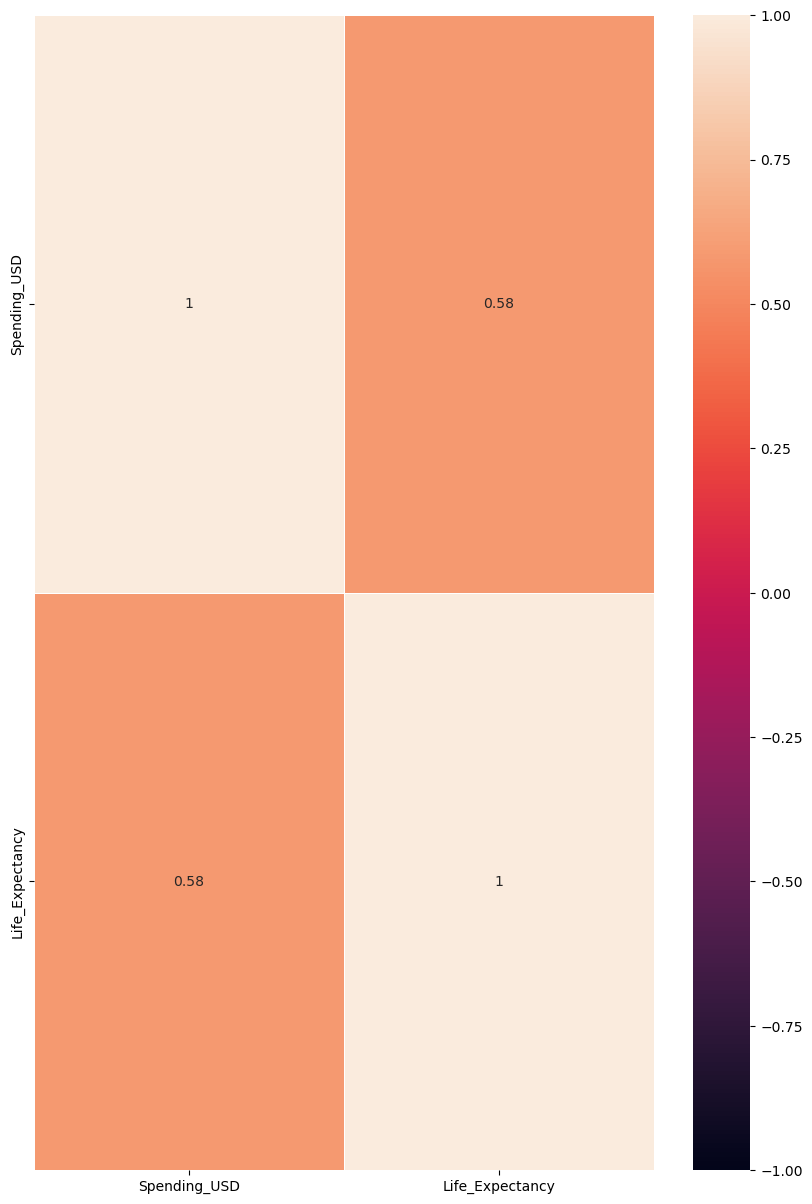

In [63]:
plt.figure(figsize=(10,15))
sns.heatmap(correlation,annot=True,color='red',vmin=-1,vmax=1,linewidths=0.5)
plt.title=" Correlation Heatmap"
plt.show()

so, there is moderate relationship between healthcare Spending and life expectancy which says that healthcare spending have effect on life expectancy but there are other factors too like:Education, environment, diet,smoking,income,etc, which may have effect on life expectancy.

Conclusion: The dataset contains no missing values, duplicate record or incorrect data type. Therefore no data cleaning was required and the analysis was performed on original dataset.